# Práctica 3 - Exploración de un dataset con pandas

## Objetivos

En esta práctica trabajarás con un dataset de clientes utilizando Python.

Al finalizar deberás ser capaz de:

- cargar datos desde un archivo CSV
- trabajar con un `DataFrame` de pandas
- identificar muestras y variables
- consultar la estructura de un dataset
- calcular estadísticas descriptivas
- seleccionar y filtrar datos
- analizar variables categóricas
- crear visualizaciones sencillas
- identificar las características \(X\) y la variable objetivo \(y\)
- determinar qué tipo de problema de Machine Learning podría resolverse

> **Importante:** no debes entrenar ningún modelo de Machine Learning en esta práctica.

## Contexto

Una empresa de telecomunicaciones quiere analizar el comportamiento de sus clientes. Dispone de información histórica y conoce qué clientes terminaron abandonando el servicio.

El objetivo futuro será desarrollar un sistema capaz de predecir:

> **¿Qué clientes tienen riesgo de abandonar la compañía?**

Para realizar la práctica utilizaremos el archivo `clientes.csv`.

| Variable | Descripción |
|---|---|
| `cliente_id` | Identificador del cliente |
| `edad` | Edad del cliente |
| `antiguedad` | Meses como cliente |
| `cuota_mensual` | Cuota mensual en euros |
| `consumo_datos` | Consumo mensual de datos en GB |
| `llamadas_soporte` | Número de llamadas a soporte |
| `incidencias` | Número de incidencias registradas |
| `tipo_contrato` | Mensual, anual o bienal |
| `satisfaccion` | Valoración del servicio de 1 a 5 |
| `abandono` | Indica si el cliente abandonó: Sí/No |

Cada fila corresponde a un cliente.

### Instrucciones

Completa las celdas de código marcadas con `# TODO`.

Cuando se solicite una interpretación, escribe tu respuesta en la celda Markdown correspondiente. No basta con ejecutar código: debes **interpretar los resultados**.

## Parte 1 - Preparación del entorno

### Ejercicio 1 - Importación

Importa NumPy, pandas y Matplotlib utilizando los alias convencionales.

In [1]:
# TODO: importa NumPy, pandas y matplotlib.pyplot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Respuesta

Explica brevemente para qué utilizaremos cada biblioteca:

- **NumPy:** Es la base sobre la que está construido pandas. Sirve para los calculos sobre arrays completos y operaciones con números.
- **pandas:** Para trabajar con tablas (dataframe). Sobre esta librería voy a cargar el CSV, consultar su estructura, calcular estadísticas y hacer el filtro de clientes.
- **Matplotlib:** Para trabajar con creación de graficos como histogramas, diagrama de barras y diagrama de dispersión

## Parte 2 - Carga e inspección inicial

### Ejercicio 2 - Cargar el dataset

Carga `clientes.csv` en un DataFrame denominado `df` y muestra sus primeras filas.

In [2]:
# TODO: carga el archivo clientes.csv en df
df = pd.read_csv("clientes.csv")
# TODO: muestra las primeras filas
df.head()

,cliente_id,edad,antiguedad,cuota_mensual,consumo_datos,llamadas_soporte,incidencias,tipo_contrato,satisfaccion,abandono
0,10001,23,61.0,32.16,11.9,1,2,Mensual,1,No
1,10002,62,79.0,45.71,17.4,2,0,Anual,2,No
2,10003,55,49.0,60.48,14.6,0,1,Mensual,5,No
3,10004,43,6.0,116.82,21.8,4,0,Anual,3,No
4,10005,43,70.0,36.13,8.8,2,2,Anual,1,Sí


### Respuesta

**¿Qué representa cada fila del DataFrame?**

Cada fila representa una muestra, es decir, un cliente

**¿Qué representa cada columna?**

Cada columna representa una variable, es decir, una característica que se mide para todos los clientes

### Ejercicio 3 - Dimensiones

Obtén mediante código las dimensiones del dataset.

In [3]:
# TODO: muestra las dimensiones del DataFrame
df.shape

(180, 10)

### Respuesta

- **Número de muestras:** 180
- **Número de variables:** 10

### Ejercicio 4 - Columnas

Obtén mediante código los nombres de todas las columnas.

In [4]:
# TODO: muestra los nombres de las columnas
df.columns

Index(['cliente_id', 'edad', 'antiguedad', 'cuota_mensual', 'consumo_datos',
       'llamadas_soporte', 'incidencias', 'tipo_contrato', 'satisfaccion',
       'abandono'],
      dtype='str')

### Respuesta

**¿Qué columna parece representar la variable que queremos predecir? ¿Por qué?**

La columna que queremos predecir es la columna `abandono` porque el objetivo de la empresa es anticiparse a qué clientes tienen riesgo de abandonar la compañía, y cuáles no, y `abandono` es precisamente la columna que recoge esa información. Además, como ya sabemos si los clientes históricos abandonaron o no, el modelo puede aprender  de ellos para estimar qué clientes nuevos podrían abandonar y cuáles no.

### Ejercicio 5 - Tipos de datos

Obtén los tipos de datos de todas las columnas.

In [5]:
# TODO: consulta los tipos de datos
df.dtypes

cliente_id            int64
edad                  int64
antiguedad          float64
cuota_mensual       float64
consumo_datos       float64
llamadas_soporte      int64
incidencias           int64
tipo_contrato           str
satisfaccion          int64
abandono                str
dtype: object

### Respuesta

**Variables numéricas:**

edad, antiguedad, cuota_mensual, consumo_datos, llamadas_soporte, incidencias, satisfaccion

**Variables categóricas:**

tipo_contrato, abandono

**¿`cliente_id` debería considerarse una característica numérica simplemente porque contiene números? Razona la respuesta.**
No. Aunque su tipo de dato es numérico (`int64`), `cliente_id` no se consideraría una variable numérica porque es un identificador: cada valor sirve únicamente para distinguir a un cliente de otro, igual que un DNI.

## Parte 3 - Estructura y calidad inicial

### Ejercicio 6 - Información general

Utiliza `info()` para analizar la estructura del dataset.

In [6]:
# TODO: muestra la información general del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cliente_id        180 non-null    int64  
 1   edad              180 non-null    int64  
 2   antiguedad        178 non-null    float64
 3   cuota_mensual     180 non-null    float64
 4   consumo_datos     179 non-null    float64
 5   llamadas_soporte  180 non-null    int64  
 6   incidencias       180 non-null    int64  
 7   tipo_contrato     180 non-null    str    
 8   satisfaccion      180 non-null    int64  
 9   abandono          180 non-null    str    
dtypes: float64(3), int64(5), str(2)
memory usage: 14.2 KB


### Respuesta

- ¿Cuántas entradas contiene?
Contiene 180 entradas
- ¿Qué tipos de datos aparecen?
Aparecen 3 float, 5 int, y 2 string
- ¿Todas las columnas contienen el mismo número de valores no nulos?
No todas contienen el mismo número de valores no nulos.
- ¿Parece existir algún valor ausente?
La columna `antiguedad` contiene 2 valores nulos, pasa lo mismo con la columna `consumo_datos` que contiene 1 valor nulo
- ¿Cómo puedes deducirlo a partir de `info()`?
Lo puedo deducir comparando el total de valores no nulos de cada columna (Not-Null Count) con el total de entradas del dataset, que según `info()` es 180. En las columnas donde hay menos de 180 valores no nulos, faltan datos.

## Parte 4 - Estadística descriptiva

### Ejercicio 7 - Descripción estadística

Obtén las estadísticas descriptivas de las variables numéricas.

In [7]:
# TODO: genera las estadísticas descriptivas
df.describe()

,cliente_id,edad,antiguedad,cuota_mensual,consumo_datos,llamadas_soporte,incidencias,satisfaccion
count,180.000000,180.000000,178.000000,180.000000,179.000000,180.000000,180.000000,180.000000
mean,10090.500000,47.283333,62.050562,71.185667,16.408380,1.705556,1.111111,3.016667
std,52.105662,15.929059,33.991071,29.279251,9.813719,1.249345,1.082563,1.423957
min,10001.000000,18.000000,1.000000,20.480000,1.200000,0.000000,0.000000,1.000000
25%,10045.750000,34.000000,34.000000,43.172500,9.800000,1.000000,0.000000,2.000000
50%,10090.500000,47.000000,61.000000,72.690000,14.300000,1.000000,1.000000,3.000000
75%,10135.250000,62.000000,91.750000,97.177500,20.400000,2.250000,2.000000,4.000000
max,10180.000000,75.000000,120.000000,119.440000,54.200000,6.000000,5.000000,5.000000


### Interpretación

A partir del resultado, indica:

- edad media;
La media de edad son 47.28 años.

- edad mínima;
La edad mínima son 18 años.

- edad máxima;
La edad máxima son 75 años.

- cuota mensual media;
La cuota mensual media son 71.19€.

- cuota mensual máxima;
La cuota mensual máxima son 119.44€.

- media de llamadas a soporte;
La media de llamadas a soporte es de 1.71.

- media de incidencias;
La media de incidencias es de 1.11.

- satisfacción media.
La satisfacción media es de 3.02 sobre una escala de 1 a 5.

Escribe aquí una breve interpretación, no solo los valores.
La columna `edad` me ha llamado la atención porque hay clientes de todas las edades, desde jóvenes hasta jubilados. La edad media de los clientes es de unos 47 años, y como la mediana también es 47, la distribución es bastante simétrica: hay edades extremas (de 18 a 75 años), pero están equilibradas a ambos lados de la media, así que la media representa bien al cliente típico.

La `cuota_mensual` media es de unos 71€, así que el cliente medio tiene una tarifa intermedia. Aun así, hay mucha diferencia entre lo que pagan unos y otros: la cuota va desde los 20€ hasta los 119€, es decir, casi 6 veces más, un indicativo de que hay tarifas diversas entre sí.

En cuanto al soporte, los clientes hacen de media 1.7 llamadas y tienen 1.1 incidencias, por lo que en general tienen pocos problemas. Sin embargo, algunos llegan a 6 llamadas o 5 incidencias, así que hay un pequeño grupo de clientes con muchos más problemas que el resto.

La satisfacción media es de 3, justo el punto medio de la escala del 1 al 5, así que en conjunto los clientes no están ni contentos ni descontentos.

### Ejercicio 8 - Cálculos individuales

Calcula mediante instrucciones independientes los valores solicitados.

In [8]:
# TODO: media de edad
print(f"Media de edad: {df['edad'].mean():.3f}")

# TODO: mediana de edad
print(f"Mediana de edad: {df['edad'].median()}")

# TODO: cuota mínima
print(f"Cuota mínima: {df['cuota_mensual'].min()}")

# TODO: cuota máxima
print(f"Cuota máxima: {df['cuota_mensual'].max()}")

# TODO: número total de incidencias
print(f"Número total de incidencias: {df['incidencias'].sum()}")

# TODO: satisfacción media
print(f"Satisfacción media: {df['satisfaccion'].mean():.3f}")

Media de edad: 47.283
Mediana de edad: 47.0
Cuota mínima: 20.48
Cuota máxima: 119.44
Número total de incidencias: 200
Satisfacción media: 3.017


### Comprobación

¿Coinciden estos resultados con los obtenidos mediante `describe()` cuando corresponde?

Sí coinciden en los valores que aparecen en `describe()`:

- La media de edad (47.283) coincide con la fila `mean` de `edad`.
- La mediana de edad (47) coincide con la fila `50%`, que es la mediana.
- La cuota mínima (20.48€) y máxima (119.44€) coinciden con las filas `min` y `max` de `cuota_mensual`.
- La satisfacción media (3.017) coincide con `mean` (3.016667), aunque aparece redondeada porque la he formateado con tres decimales.

El número total de incidencias (200) no aparece en `describe()`, ya que no incluye la suma. Aun así se puede comprobar: si multiplico la media de incidencias (1.111) por el número de clientes (180), sale 200.

## Parte 5 - Selección de información

### Ejercicio 9 - Selección de columnas

Crea un DataFrame `df_clientes` que contenga únicamente `edad`, `antiguedad`, `cuota_mensual`, `satisfaccion` y `abandono`. Muestra sus primeras cinco filas.

In [9]:
# TODO: crea df_clientes
filtro = [
    'edad', 
    'antiguedad', 
    'cuota_mensual', 
    'satisfaccion', 
    'abandono'
]

df_clientes = df[filtro]

# TODO: muestra las primeras cinco filas
df_clientes.head()

,edad,antiguedad,cuota_mensual,satisfaccion,abandono
0,23,61.0,32.16,1,No
1,62,79.0,45.71,2,No
2,55,49.0,60.48,5,No
3,43,6.0,116.82,3,No
4,43,70.0,36.13,1,Sí


### Respuesta

**¿Sigue representando cada fila al mismo cliente que en el DataFrame original? Explica por qué.**

Sí. Seleccionar columnas no elimina ni reordena ninguna fila: solo quitamos variables, pero cada fila sigue conteniendo los datos del mismo cliente. Se puede comprobar porque el índice se mantiene (0, 1, 2...) y los valores coinciden con el DataFrame original. Por ejemplo, la fila 0 sigue teniendo al cliente de 23 años, con 61 meses de antigüedad y una cuota de 32.16€.

## Parte 6 - Filtrado

### Ejercicio 10 - Clientes por edad

Obtén todos los clientes mayores de 50 años y calcula cuántos cumplen la condición.

In [10]:
# TODO: filtra los clientes mayores de 50 años
filtro_mayores_50 = df['edad'] > 50

# TODO: calcula cuántos son
mayores_50 = df[filtro_mayores_50]
print(f"Mayores de 50: {len(mayores_50)}")

Mayores de 50: 77


### Ejercicio 11 - Clientes con incidencias

Selecciona los clientes que tengan `incidencias > 0` y determina cuántos son.

In [11]:
# TODO: filtra los clientes con incidencias
filtro = df['incidencias'] > 0
df_incidencias = df[filtro]
columnas = ['cliente_id', 'incidencias', 'satisfaccion']
print(df_incidencias[columnas])

# TODO: calcula cuántos son
print("Clientes con incidencias:", len(df_incidencias))

     cliente_id  incidencias  satisfaccion
0         10001            2             1
2         10003            1             5
4         10005            2             1
5         10006            2             2
6         10007            2             3
..          ...          ...           ...
169       10170            1             1
173       10174            1             2
174       10175            2             4
175       10176            1             3
178       10179            1             3

[120 rows x 3 columns]
Clientes con incidencias: 120


### Ejercicio 12 - Condiciones combinadas

Obtén los clientes que cumplan simultáneamente:

$$
edad < 30
$$

y

$$
llamadas\_soporte \geq 3
$$

Muestra únicamente `cliente_id`, `edad`, `llamadas_soporte` y `abandono`.

In [12]:
# TODO: realiza el filtro y muestra únicamente las columnas solicitadas
filtro = (df['edad'] < 30) & (df['llamadas_soporte'] >= 3)
df_filtrado = df[filtro]
columnas = ['cliente_id', 'edad', 'llamadas_soporte', 'abandono']
print(df_filtrado[columnas])

     cliente_id  edad  llamadas_soporte abandono
17        10018    25                 3       No
22        10023    28                 3       No
35        10036    21                 3       Sí
55        10056    20                 3       No
101       10102    29                 3       No
117       10118    26                 3       Sí
119       10120    24                 3       No
132       10133    23                 4       No
146       10147    20                 3       No
167       10168    27                 6       Sí
169       10170    19                 3       Sí


### Respuesta

**¿Qué operador has utilizado para combinar ambas condiciones?**

Escribe aquí tu respuesta.

### Ejercicio 13 - Segundo filtro combinado

Localiza clientes que cumplan:

$$
satisfaccion \leq 2
$$

y

$$
incidencias \geq 2
$$

Muestra las filas encontradas.

In [13]:
# TODO: realiza el filtro
filtro = (df['satisfaccion'] <= 2) & (df['incidencias'] >= 2)
df_filtrado = df[filtro]
print(f"Numero de filas: {df_filtrado.shape[0]}")
df_filtrado

Numero de filas: 26


,cliente_id,edad,antiguedad,cuota_mensual,consumo_datos,llamadas_soporte,incidencias,tipo_contrato,satisfaccion,abandono
0,10001,23,61.0,32.16,11.9,1,2,Mensual,1,No
4,10005,43,70.0,36.13,8.8,2,2,Anual,1,Sí
5,10006,67,3.0,105.63,15.8,2,2,Bienal,2,No
11,10012,74,27.0,61.04,5.2,0,5,Mensual,1,Sí
19,10020,44,55.0,39.62,3.8,1,2,Mensual,1,No
20,10021,47,18.0,37.98,27.6,0,2,Mensual,2,Sí
24,10025,63,23.0,40.24,7.8,2,2,Mensual,1,Sí
25,10026,55,34.0,50.03,16.1,1,2,Anual,2,Sí
35,10036,21,115.0,41.06,27.0,3,2,Bienal,1,Sí
44,10045,21,119.0,40.48,16.0,1,2,Mensual,1,No


### Reflexión

**Observando únicamente estos resultados, ¿podemos afirmar que una satisfacción baja provoca el abandono?**

No. De los 26 clientes con satisfacción baja e incidencias altas, 18 abandonaron, pero eso solo muestra que ambas cosas aparecen juntas (correlación), no que la satisfacción baja provoque el abandono. Además, el filtro también incluye las incidencias, así que el abandono podría deberse a ellas y no a la satisfacción. Y con solo 26 clientes la muestra es demasiado pequeña para sacar una conclusión.

## Parte 7 - Variables categóricas

### Ejercicio 14 - Tipo de contrato

Obtén los diferentes valores de `tipo_contrato` y calcula cuántos clientes pertenecen a cada categoría.

In [14]:
# TODO: muestra las categorías existentes
print(f"Categorias: {df['tipo_contrato'].unique().tolist()}")

# TODO: calcula la frecuencia de cada categoría
print(f"\nFrecuencia de cada categoría: {df['tipo_contrato'].value_counts()}")

Categorias: ['Mensual', 'Anual', 'Bienal']

Frecuencia de cada categoría: tipo_contrato
Mensual    94
Anual      56
Bienal     30
Name: count, dtype: int64


### Respuesta

**¿Cuál es el tipo de contrato más frecuente?**

El tipo de contrato más frecuente es el **Mensual**, con 94 clientes (un 52.2% del total), seguido del Anual con 56 (31.1%) y el Bienal con 30 (16.7%). Es decir, más de la mitad de los clientes tienen un contrato sin permanencia a largo plazo.

### Ejercicio 15 - Variable `abandono`

Obtén las categorías existentes, el número de clientes de cada categoría y sus frecuencias relativas.

In [15]:
# TODO: categorías existentes
print(f"Categorias: {df['abandono'].unique().tolist()}")

# TODO: frecuencias absolutas
print(f"\nFrecuencia absoluta: {df['abandono'].value_counts()}")

# TODO: frecuencias relativas
print(f"\nFrecuencia relativa: {df['abandono'].value_counts(normalize=True)}")

Categorias: ['No', 'Sí']

Frecuencia absoluta: abandono
No    110
Sí     70
Name: count, dtype: int64

Frecuencia relativa: abandono
No    0.611111
Sí    0.388889
Name: proportion, dtype: float64


### Interpretación

Expresa las frecuencias relativas mediante porcentajes y redacta una breve conclusión sobre la distribución de `abandono`.

El 61.1% de los clientes no abandonó la compañía (110 clientes), mientras que el 38.9% sí lo hizo (70 clientes). Aunque la mayoría se queda, el abandono es elevado: aproximadamente 4 de cada 10 clientes se van, lo que justifica el interés de la empresa por predecirlo. Además, las dos clases no están igual de representadas (hay más "No" que "Sí"), algo a tener en cuenta antes de entrenar un modelo.

## Parte 8 - Visualización

Todos los gráficos deben contener como mínimo:

- título;
- etiquetas de los ejes cuando correspondan;
- una representación clara.

### Ejercicio 16 - Distribución de edad

Construye un histograma de `edad`.

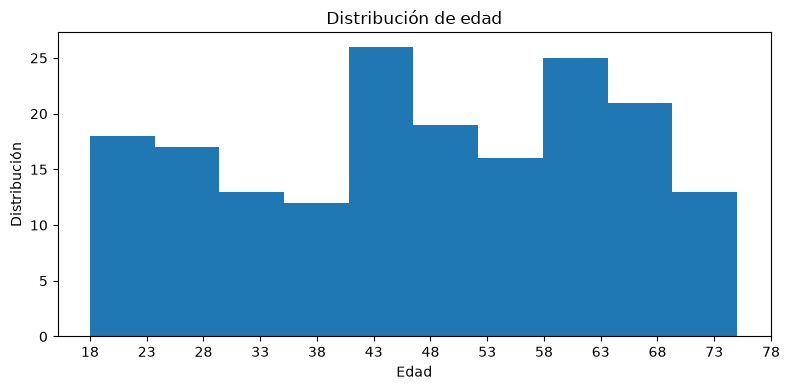

In [16]:
# TODO: crea el histograma de edad
plt.figure(figsize=(8, 4))
plt.hist(df['edad'], bins=10)
plt.xticks(range(18, 80, 5))
plt.xlabel("Edad")
plt.ylabel("Distribución")
plt.title("Distribución de edad")
plt.tight_layout()
plt.show()

### Interpretación

**¿Qué información proporciona un histograma que no resulta tan fácil obtener observando directamente las filas del DataFrame?**

Se resume de forma gráfica y fácil de entender cuál es la distribución de los clientes entre 18 y 75 años en función de los valores de la variable. Los mayores rangos se encuentran entre los clientes de 41 a 46 y 58 a 63; los de menos entre 29 a 41 y por encima de 69. No se presentan valores atípicos.

Este análisis resulta muy complicado si se analizan las 180 filas del csv, siendo de esta manera muy práctico.

### Ejercicio 17 - Abandono

Representa mediante un gráfico de barras el número de clientes que abandonaron y que no abandonaron.

Index(['No', 'Sí'], dtype='str', name='abandono')
[0.61111111 0.38888889]


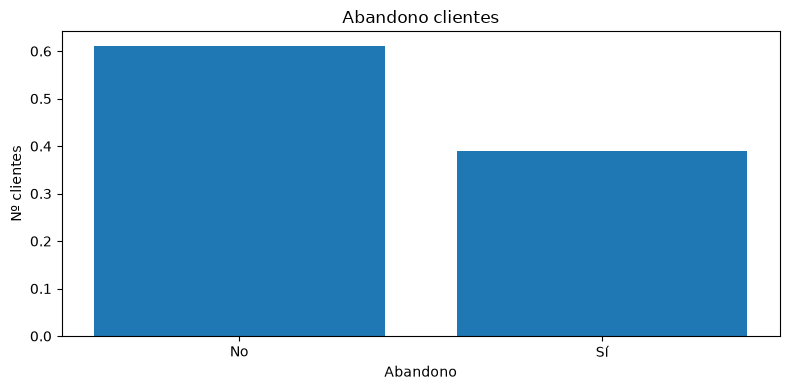

In [ ]:
# TODO: crea el gráfico de barras
n_abandonos = df['abandono'].value_counts()
print(n_abandonos.index)
print(n_abandonos.values)

plt.figure(figsize=(8, 4))
plt.bar(n_abandonos.index, n_abandonos.values)
plt.xlabel("Abandono")
plt.ylabel("Nº clientes")
plt.title("Abandono clientes")
plt.tight_layout()
plt.show()

### Interpretación

Describe brevemente qué muestra el gráfico.

Lo que nos indica este gráfico es el porcentaje de clientes que abandonan y no abandonan. En este caso concreto, el 61% de los clientes no abandonaron y el 38.9% sí lo hizo. Esta información es muy importante ya que el porcentaje de abandonos es alto, y habría que centrarse en los factores que han influido para corregir e intentar disminuir el porcentaje.

### Ejercicio 18 - Cuota mensual

Crea un histograma para `cuota_mensual`.

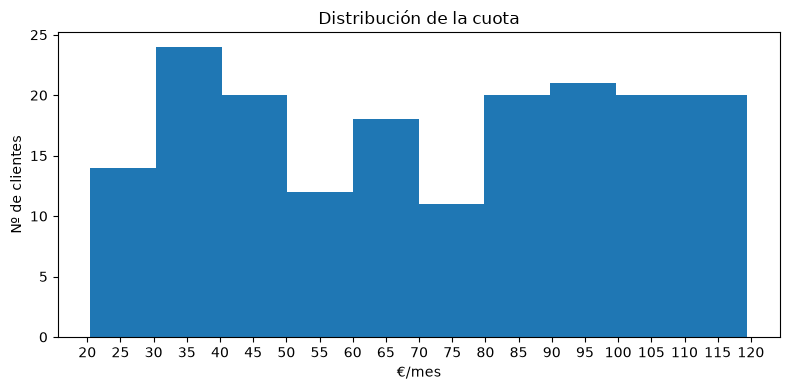

In [18]:
# TODO: crea el histograma de cuota_mensual
plt.figure(figsize=(8, 4))
plt.hist(df['cuota_mensual'], bins=10)
plt.xticks(range(20, 125, 5))
plt.xlabel("€/mes")
plt.ylabel("Nº de clientes")
plt.title("Distribución de la cuota")
plt.tight_layout()
plt.show()

### Interpretación

Analiza visualmente la distribución.

Este gráfico muestra el número de clientes en función de la cuota. Es muy cómodo de interpretar donde muestra que el mayor número de clientes, 24 pagan entre 30 y 40 €, y que a partir de los 80 € hasta los 120 son las cuotas donde la distribución de clientes es más estable

### Ejercicio 19 - Edad y cuota

Crea un diagrama de dispersión utilizando:

$$
x = edad
$$

$$
y = cuota\_mensual
$$

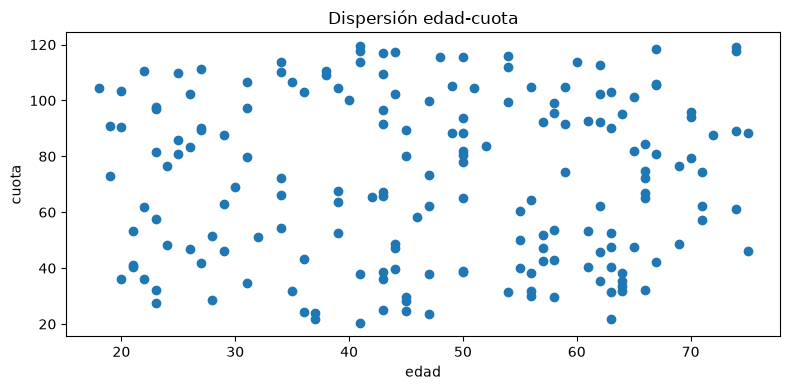

In [19]:
# TODO: crea el diagrama de dispersión
plt.figure(figsize=(8, 4))
plt.scatter(df['edad'], df['cuota_mensual'])
plt.xlabel("edad")
plt.ylabel("cuota")
plt.title("Dispersión edad-cuota")
plt.tight_layout()
plt.show()

### Interpretación

- ¿Qué representa cada punto?

Cada punto representa la relación de edad de un cliente en función de la cuota y la edad.

- ¿Observas a simple vista alguna relación clara entre ambas variables?

No es necesario realizar un análisis estadístico.

En este gráfico se muestra una gran dispersión de datos. Por ejemplo muestra una mayor concentración entre los clientes de 55 y 65 años para las cuotas entre 35 y 60 €, pero a mi entender no es muy significativa la dispersión que muestra.

## Parte 9 - Identificación de $X$ e $y$

La empresa quiere construir en el futuro un modelo que determine si un cliente abandonará.

### Ejercicio 20 - Variable objetivo

Identifica y crea `y`. Después muestra sus cinco primeros valores.

In [20]:
# TODO: crea y
y = df['abandono']

# TODO: muestra sus cinco primeros valores
y.head()

0    No
1    No
2    No
3    No
4    Sí
Name: abandono, dtype: str

### Respuesta

**¿Por qué esta variable corresponde a \(y\)?**

La variable `abandono` corresponde a `y`, que es la variable objetivo. Lo que pretende predecir el modelo de la compañía es si un cliente futuro que tenga entrada en la compañía tiene posibilidades de abandonar o no la empresa.

### Ejercicio 21 - Características

Crea `X` utilizando inicialmente estas características:

- `edad`
- `antiguedad`
- `cuota_mensual`
- `consumo_datos`
- `llamadas_soporte`
- `incidencias`
- `tipo_contrato`
- `satisfaccion`

Después comprueba sus dimensiones.

In [ ]:
# TODO: crea X
X =  df[[
    'edad', 
    'antiguedad', 
    'cuota_mensual', 
    'consumo_datos', 
    'llamadas_soporte', 
    'incidencias', 
    'tipo_contrato', 
    'satisfaccion'
    ]]

# TODO: muestra las dimensiones de X
print(X.shape)

(180, 8)


### Respuesta

Si el dataset contiene \(n\) clientes, esperamos:

$$
X.shape = (n,\ ?)
$$

**¿Qué número debe aparecer en `?`? ¿Por qué?**

En `?` debe aparecer el número 8, que son las características o las columnas que hemos seleccionado para `X`. Aparece `8` porque son las variables que usamos para entrenar al modelo.

Dejamos fuera dos columnas del dataset

## Parte 10 - Razonamiento de Machine Learning

### Ejercicio 22 - Identificación del problema

Queremos predecir:

`abandono → Sí / No`

Responde razonadamente:

1. ¿Estamos ante aprendizaje supervisado o no supervisado?

Aprendizaje supervisado.

2. ¿Por qué?

Es aprendizaje supervisado porque tenemos suficientes ejemplos de clientes que tienen posibilidades de abandonar o no.

3. ¿Es clasificación o regresión?

Es una clasificación binaria

4. ¿Por qué?

Porque queremos predecir una categoría o en este caso una etiqueta.

5. ¿Es clasificación binaria o multiclase?

Es una clasificación binaria porque el resultado del abandono es `Sí` o `No`.

6. ¿Cuáles son las clases?

Las clases son: `Sí` y `No`, dependiendo si el cliente abandona o no

### Respuesta

Se trata de un problema de aprendizaje supervisado, porque los datos históricos están etiquetados: para cada cliente sabemos si abandonó o no la compañía, de modo que un modelo podría aprender a partir de estos ejemplos.

Además, es un problema de clasificación, ya que la variable objetivo `abandono` no es un número continuo, sino una categoría que contiene dos etiquetas: `Sí` y `No`. En este caso es una clasificación binaria, ya que existen únicamente dos posibles respuestas: `Sí` para el cliente que abandona y `No` para el cliente que no abandona.

## Parte 11 - Un cambio en el problema

Supongamos ahora que la empresa plantea:

> Queremos predecir cuál será el **consumo de datos del próximo mes** de cada cliente.

### Ejercicio 23

Responde:

1. ¿Cuál sería ahora la variable objetivo?

Ahora la variable objetivo en lugar de `abandono` es una variable nueva `consumo_datos_mes_siguiente` que no está en el dataset.

2. ¿Seguiríamos teniendo exactamente el mismo \(X\)?

No porque los clientes que han abandonado ya no tendrán consumo del mes que viene, y habría que excluirlos del análisis

3. ¿Sería clasificación o regresión?

Regresión porque ahora queremos predecir un valor numérico.

4. ¿Seguiría siendo aprendizaje supervisado?

Sí, si seguimos disponiendo de datos históricos que conozcamos el consumo real.

5. Justifica cada respuesta.

### Respuesta

Al cambiar la pregunta de negocio cambia el problema de Machine Learning, la variable objetivo pasa a ser numérica, por lo que pasamos de clasificación a regresión, el aprendizaje sigue siendo supervisado porque necesitamos ejemplos con la respuesta conocida. El tipo de problema no depende del dataset, sino de qué queremos predecir.

## Parte 12 - Análisis crítico

### Ejercicio 24 - ¿Utilizarías `cliente_id`?

Los identificadores tienen valores como:

`10001, 10002, 10003, 10004, ...`

¿Utilizarías esta columna como característica para predecir el abandono?

No respondas únicamente «sí» o «no». Razona tu decisión.

### Respuesta

No, porque el id no determina la posibilidad de abandono. `cliente_id` solo distingue clientes, no identifica nada más, y está asignado por orden de alta.

### Ejercicio 25 - ¿Estamos preparados para entrenar?

Después del análisis anterior, alguien propone ejecutar directamente:

```python
modelo.fit(X, y)
```

¿Estamos preparados?

Identifica **al menos cuatro cuestiones** que deberíamos estudiar o resolver antes de entrenar el modelo.

No necesitas explicar todavía cómo resolverlas.

### Respuesta

1. Valores nulos
2. Variables categóricas
3. Variable objetivo en texto
4. Separación de datos

## Parte 13 - Conclusiones

### Ejercicio 26 - Informe final

Escribe entre **8 y 12 líneas** resumiendo lo que has descubierto.

Debes incluir como mínimo:

- tamaño del dataset
- principales tipos de variables
- comportamiento de `abandono`
- alguna observación de las estadísticas
- alguna observación de las visualizaciones
- cuáles son \(X\) e \(y\)
- tipo de problema de Machine Learning
- qué pasos deberían realizarse antes de entrenar

### Conclusiones

El dataset contiene información de 180 clientes y 10 variables. La mayoría son numéricas (edad, antigüedad, cuota mensual, consumo de datos, llamadas a soporte, incidencias y satisfacción), mientras que `tipo_contrato` y `abandono` son categóricas, y `cliente_id` es solo un identificador que no aporta información para predecir.

En cuanto a `abandono`, el 61.1% de los clientes se quedó y el 38.9% abandonó la compañía, es decir, unos 4 de cada 10 clientes se van. Las estadísticas muestran una edad media de unos 47 años, muy similar a la mediana, una cuota media de 71 € y una satisfacción media de 3.02 sobre 5. Además, más de la mitad de los clientes (52.2%) tiene contrato mensual.

En las visualizaciones se observa que tanto la edad como la cuota están repartidas de forma bastante uniforme, sin un grupo que domine, y que no se aprecia una relación clara entre edad y cuota.

La variable objetivo \(y\) es `abandono`, y \(X\) está formada por las 8 características restantes, sin `cliente_id`. Se trata de un problema de aprendizaje supervisado de clasificación binaria. Antes de entrenar habría que tratar los valores nulos, convertir las variables de texto a valores numéricos, tener en cuenta el desbalance de clases y separar los datos en entrenamiento.

---

# Ampliación opcional

Si terminas antes, investiga cómo obtener con pandas:

1. El número exacto de valores ausentes de cada columna.
2. El número de clientes agrupados por `tipo_contrato` y `abandono`.
3. La cuota mensual media de quienes abandonaron y de quienes no.
4. La satisfacción media de ambos grupos.

No utilices algoritmos de Machine Learning.

In [22]:
# AMPLIACIÓN OPCIONAL

# 1. Valores ausentes por columna


# 2. Clientes agrupados por tipo_contrato y abandono


# 3. Cuota mensual media según abandono


# 4. Satisfacción media según abandono

# Antes de entregar

Comprueba que:

- has completado todas las celdas `TODO`
- has respondido las preguntas en Markdown
- todos los gráficos tienen título y etiquetas
- has reiniciado el entorno y ejecutado el notebook completo desde el principio
- no se producen errores
- no has entrenado ningún modelo

**Nombre recomendado del archivo de entrega:**

`Practica_03_Apellido_Nombre.ipynb`